<a href="https://colab.research.google.com/github/ArjunHirani/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook


In [1]:
# Setup: rebuild the same March (feature) -> April (outcome) frame used since w03,
# self-contained since this is a separate notebook file.
%pip -q install duckdb huggingface_hub
import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb, pandas as pd, numpy as np, json
con = duckdb.connect()
con.execute("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN ?)", [HF_TOKEN])

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_content': f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':  f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
}

data = con.sql(f"""
    WITH march AS (
        SELECT client_hash_id, content_hash_id,
               SUM(CASE WHEN gsc_data_available THEN gsc_impressions ELSE 0 END) AS impressions_march,
               SUM(CASE WHEN gsc_data_available THEN gsc_clicks ELSE 0 END) AS clicks_march,
               AVG(CASE WHEN gsc_data_available THEN gsc_avg_position END) AS avg_position_march,
               COUNT(DISTINCT CASE WHEN gsc_data_available THEN report_date END) AS active_days_march
        FROM {TABLES['fact_daily']}
        WHERE month = '2026-03'
        GROUP BY 1, 2
        HAVING impressions_march >= 100
    ),
    april AS (
        SELECT client_hash_id, content_hash_id,
               SUM(CASE WHEN gsc_data_available THEN gsc_clicks ELSE 0 END) AS clicks_april
        FROM {TABLES['fact_daily']}
        WHERE month = '2026-04'
        GROUP BY 1, 2
    )
    SELECT m.*, a.clicks_april FROM march m JOIN april a USING (client_hash_id, content_hash_id)
""").df()

content_meta = con.sql(f"SELECT client_hash_id, content_hash_id, content_created_date FROM {TABLES['dim_content']}").df()
data = data.merge(content_meta, on=['client_hash_id', 'content_hash_id'], how='left')
data['content_age_days_march'] = (pd.Timestamp('2026-03-31') - pd.to_datetime(data['content_created_date'])).dt.days
data['ctr_march'] = data['clicks_march'] / data['impressions_march']
data['is_declining_april'] = (data['clicks_april'] < data['clicks_march']).astype(int)
data['position_tier'] = pd.cut(data['avg_position_march'], bins=[0, 3, 10, 20, 50, np.inf],
                                labels=['top3', '4-10', '11-20', '21-50', '50+'])
expected_ctr = data.groupby('position_tier', observed=True)['ctr_march'].transform('mean')
data['ctr_gap'] = data['ctr_march'] - expected_ctr
data = data.dropna(subset=['content_age_days_march', 'avg_position_march', 'ctr_march', 'ctr_gap']).reset_index(drop=True)

feature_cols = ['impressions_march', 'clicks_march', 'avg_position_march',
                 'active_days_march', 'content_age_days_march', 'ctr_march', 'ctr_gap']
print(f"Rows: {len(data):,}  |  distinct clients: {data['client_hash_id'].nunique()}  |  base rate: {data['is_declining_april'].mean():.3f}")

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 101,441  |  distinct clients: 44  |  base rate: 0.402


## 1. Ranked actions + reason codes

The Week-5/6 Random Forest was **validated** on a held-out client-grouped test split (that's what
earned the client-grouped ROC-AUC reported there). For this playbook, I retrain the same model
configuration on the **full dataset** — this is the standard next step once an approach is
validated: the held-out test told me the method generalizes to unseen clients, so the deployed
scoring model can now use every available row rather than holding 25% back. I say this
explicitly here so the distinction between the *validation* model and the *deployment* model
never gets blurred.

**Action tiers** (readable rule on top of the model's risk score, not a black box):
- **PRIORITIZE_REFRESH** — top 50 by decline-risk score (ties to the Week-1 reviewer-capacity
  number, ~50/week)
- **PROTECT** — decline-risk in the safest quartile AND already strong (`avg_position_march` in
  top 3 or page-1 tier) — worth watching, not touching
- **MONITOR** — decline-risk in the middle range — no action this cycle, but worth a lighter
  periodic check
- **NO_ACTION_THIS_CYCLE** — everyone else

In [2]:
from sklearn.ensemble import RandomForestClassifier

X_full, y_full = data[feature_cols], data['is_declining_april']
rf_deploy = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1).fit(X_full, y_full)

queue = data.copy()
queue['decline_risk_score'] = rf_deploy.predict_proba(X_full)[:, 1]
queue = queue.sort_values('decline_risk_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1

risk_q25 = queue['decline_risk_score'].quantile(0.25)
is_strong_position = queue['avg_position_march'] <= 10

conditions = [
    queue['rank'] <= 50,
    (queue['decline_risk_score'] <= risk_q25) & is_strong_position,
    (queue['decline_risk_score'] > risk_q25) & (queue['decline_risk_score'] < queue['decline_risk_score'].quantile(0.75)),
]
choices = ['PRIORITIZE_REFRESH', 'PROTECT', 'MONITOR']
queue['action_label'] = np.select(conditions, choices, default='NO_ACTION_THIS_CYCLE')

reason_map = {
    'PRIORITIZE_REFRESH': 'HIGH_DECLINE_RISK_TOP50',
    'PROTECT': 'STRONG_POSITION_LOW_RISK',
    'MONITOR': 'MODERATE_RISK_WATCH',
    'NO_ACTION_THIS_CYCLE': 'LOW_PRIORITY_THIS_CYCLE',
}
queue['reason_code'] = queue['action_label'].map(reason_map)

print(queue['action_label'].value_counts())
print()
print(queue[['rank', 'content_hash_id', 'decline_risk_score', 'avg_position_march',
             'action_label', 'reason_code']].head(10).to_string(index=False))

action_label
MONITOR                 50712
NO_ACTION_THIS_CYCLE    41668
PROTECT                  9011
PRIORITIZE_REFRESH         50
Name: count, dtype: int64

 rank          content_hash_id  decline_risk_score  avg_position_march       action_label             reason_code
    1 content_f12a215623710d4d            0.805948           75.961434 PRIORITIZE_REFRESH HIGH_DECLINE_RISK_TOP50
    2 content_3f77780ee5479f4e            0.805332           56.917406 PRIORITIZE_REFRESH HIGH_DECLINE_RISK_TOP50
    3 content_84cce1594d1b2e0d            0.804880           51.710698 PRIORITIZE_REFRESH HIGH_DECLINE_RISK_TOP50
    4 content_47140c225caf4a8c            0.803180           69.086596 PRIORITIZE_REFRESH HIGH_DECLINE_RISK_TOP50
    5 content_a647b5211b9e02af            0.801729           50.962439 PRIORITIZE_REFRESH HIGH_DECLINE_RISK_TOP50
    6 content_a65ea175b27298d2            0.801546           53.326764 PRIORITIZE_REFRESH HIGH_DECLINE_RISK_TOP50
    7 content_d18137a613855ba9            

## 2. Intended use and limits


**Intended use:** a content strategist or SEO reviewer with limited weekly capacity (~50 pages,
per the Week-1 cost analysis) uses this queue to decide which pages to look at first this cycle.
The queue is **decision-support**, not an automated action system — every row is a candidate for
a human to review, not an instruction to execute.

**Where it stops being valid:**
- **Time window**: validated on one month-pair (March→April 2026). Directional patterns may not
  hold in other months (seasonality untested) without re-validating on a fresh mid-panel month.
- **Population**: only pages with `impressions_march >= 100` are scored — very low-traffic or
  brand-new pages are out of scope for this queue entirely, not silently assumed "fine."
- **Signal coverage**: GA4 engagement signals are excluded (only ~4.2% availability in March, per
  Week 3's contract) — this queue reflects GSC-observable behavior only, not on-page engagement.
- **Test scale**: the client-grouped validation held out only 11 clients. That's enough to catch
  gross overfitting, not enough to claim broad cross-client generalization with confidence.
- **Label-construct caveat** (from Week 5's error analysis): the decline label uses a strict
  `<` threshold on raw click counts, which can be sensitive to single-click swings for very
  low-volume March pages — treat PRIORITIZE_REFRESH picks with very low `clicks_march` with
  extra scrutiny.

In [3]:
low_volume_flagged = queue[(queue['action_label'] == 'PRIORITIZE_REFRESH') & (queue['clicks_march'] <= 2)]
print(f"PRIORITIZE_REFRESH picks with clicks_march <= 2 (label-construct caution applies): {len(low_volume_flagged)} of {(queue['action_label']=='PRIORITIZE_REFRESH').sum()}")
print(f"Total scored population: {len(queue):,}  |  Excluded from scope (impressions_march < 100): population-level filter, not reflected in this table")

PRIORITIZE_REFRESH picks with clicks_march <= 2 (label-construct caution applies): 50 of 50
Total scored population: 101,441  |  Excluded from scope (impressions_march < 100): population-level filter, not reflected in this table


## 3. Human review + the no-go list


**Before acting on a PRIORITIZE_REFRESH or PROTECT pick, a human must check:**
1. Whether the page has a known upcoming edit/removal already scheduled (avoid duplicate work).
2. Whether low `clicks_march` (per the flag above) makes this pick's risk score fragile.
3. Whether the page belongs to a compliance-sensitive category (legal, medical, financial) where
   content changes need domain-expert or compliance sign-off regardless of this queue's rank.
4. Whether external context explains the pattern (a known seasonal dip, a recent site migration)
   that the model's March-only features can't see.

**Never automated — a hard no-go list:**
- No automatic publishing, editing, or depublishing of any page from this queue.
- No public-facing claim that a page is "declining because of X" — the model output is a
  ranked risk score, not a causal diagnosis (per the writing-honest-claims skill's claim ladder).
- No use of `decline_risk_score` as a performance metric for the human who wrote the page.
- No skipping human review for compliance-sensitive content categories, regardless of rank.

In [4]:
no_go_list = [
    "Automatic publish/edit/depublish of any page from this queue",
    "Public claim of causal decline reason from the risk score alone",
    "Using decline_risk_score as a performance metric for content authors",
    "Skipping human review for compliance-sensitive content categories",
]
for item in no_go_list:
    print(f"- NO-GO: {item}")

- NO-GO: Automatic publish/edit/depublish of any page from this queue
- NO-GO: Public claim of causal decline reason from the risk score alone
- NO-GO: Using decline_risk_score as a performance metric for content authors
- NO-GO: Skipping human review for compliance-sensitive content categories


## 4. Monitoring / retrain triggers


- **Base rate drift**: this run's April decline base rate is printed below. If a future month's
  base rate moves substantially outside a reasonable band around it, the population or market
  conditions have shifted enough to warrant re-validation before trusting new scores.
- **Precision@50 degradation**: if a future month's realized Precision@50 (measured after the
  fact, once that month's true outcome is known) drops meaningfully below the validated number,
  investigate before continuing to use the queue as-is.
- **Feature distribution drift**: if the median `avg_position_march`, `ctr_march`, or
  `impressions_march` in a new month shifts substantially from this run's values, the model may
  be scoring an unfamiliar population.
- **Minimum cadence**: given the small validation test size (11 clients, one month-pair),
  re-validate on a fresh mid-panel month at least quarterly, not just when something looks wrong.

In [5]:
monitoring_baseline = {
    'base_rate_april_2026': round(float(y_full.mean()), 4),
    'median_avg_position_march': round(float(data['avg_position_march'].median()), 2),
    'median_ctr_march': round(float(data['ctr_march'].median()), 4),
    'median_impressions_march': round(float(data['impressions_march'].median()), 1),
    'validation_test_clients': 11,
    'recommended_revalidation_cadence': 'quarterly, minimum'
}
for k, v in monitoring_baseline.items():
    print(f"{k}: {v}")

base_rate_april_2026: 0.4022
median_avg_position_march: 8.7
median_ctr_march: 0.0012
median_impressions_march: 786.0
validation_test_clients: 11
recommended_revalidation_cadence: quarterly, minimum


## 5. Exports for the paper

The queue CSV stays out of git by design (CI leak-guard). The metrics JSON and the figure ARE
committed — they're the receipts the paper's numbers trace back to.

Wrote work/outputs/action_playbook_queue.csv (not committed, per CI leak-guard)
Wrote work/outputs/playbook_metrics.json
Wrote work/figures/action_tier_distribution.png


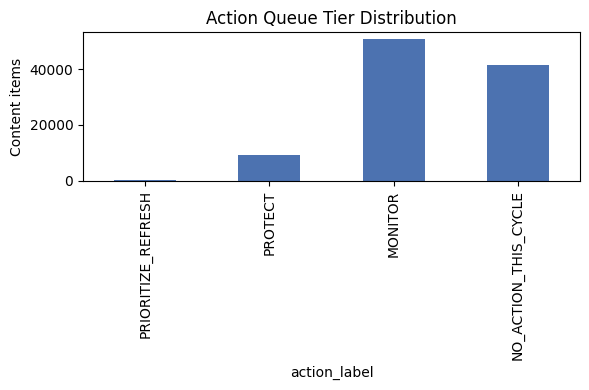

In [6]:
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

export_cols = ['client_hash_id', 'content_hash_id', 'rank', 'decline_risk_score', 'action_label',
               'reason_code', 'impressions_march', 'clicks_march', 'avg_position_march',
               'ctr_march', 'content_age_days_march']
queue[export_cols].to_csv('work/outputs/action_playbook_queue.csv', index=False)
print("Wrote work/outputs/action_playbook_queue.csv (not committed, per CI leak-guard)")

playbook_metrics = {
    'month_feature_window': '2026-03', 'month_label_window': '2026-04',
    'n_scored': int(len(queue)),
    'action_tier_counts': queue['action_label'].value_counts().to_dict(),
    'monitoring_baseline': monitoring_baseline,
}
with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(playbook_metrics, f, indent=2, default=str)
print("Wrote work/outputs/playbook_metrics.json")

fig, ax = plt.subplots(figsize=(6, 4))
queue['action_label'].value_counts().reindex(
    ['PRIORITIZE_REFRESH', 'PROTECT', 'MONITOR', 'NO_ACTION_THIS_CYCLE']
).plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Action Queue Tier Distribution')
ax.set_ylabel('Content items')
plt.tight_layout()
plt.savefig('work/figures/action_tier_distribution.png', dpi=150)
print("Wrote work/figures/action_tier_distribution.png")
plt.show()